### **RAG**

#### **Theory & Introduction**

##### **What is RAG**

Retrieval Augmented Generation (RAG) is a technique that helps an LLM answer questions using external data such as PDFs, documents, websites, databases, or company knowledge bases. Simply, RAG gives relevant context to the LLM before answering

1) **Retrieval** : Finding relevant information from documents
2) **Augmentation** : Adding that retrieved information as extra context to the user question.This is like improving the LLMs input by adding retrieved context. 
3) **Generation** : LLM generates the final answer using that context. 

**Example:**

Q) What is the refund policy of the company?

The LLM may not know this because company policy is private data

RAG does this : 
1) It searches the company policy document.
2) It retrieves the relevant refund policy section.
3) It adds that retrieved section as extra context to the user question.
4) It gives the context + question to the LLM. 
5) The LLM generates the final answer based on that context. 

**General Process**

LLMs do not have access to the latest information

                ↓

We retrieve relevant context from documents

                ↓

We provide the LLM with the retrieved context + user's question

                ↓

LLM generates a grounded answer


**Flow :**  

User Q) What is the refund policy of the company?

Retrieved context : Refunds are allowed within 7 days of purchase. *This is generated using similiarity search*

Augmented Prompt : Q) What is the refund policy of the company? Context : Refunds are allowed within 7 days of purchase. *This exactly as a whole is passed to the LLM*

Final Answer : The refund policy allows refunds within 7 days of purchase. 

Chunking is like an optional step

User query is not passed to LLM, we first create embedding and we give that to VDB. For the user query, we first create embeddings and send them to vector database. Inside the Vector DB, we perform similarity search operation, we find the relevant chunk which is called retrieval stage and we get the top-k retrieved chunks. Separately, we send the prompt, retrieved context and combine them to send to LLM where the LLM finally gives us an answer. 

Search what is **Vectorless RAG**, this is not a magic too. This may or maynot work always and this is not a replacement of Vector RAG. 



Unlike an AI assistant where we give the input directly to the assistant and get the output, for RAG We are augmenting the input and then we give that to LLM. Basically we are adding more context to the input. 

1) Data Ingestion / Data Parsing (Document AI) : 
2) Retrieval : 
3) Generation : 

Careful emphasis needs to be given on data ingestion and data parsing along with Retrieval.
Generation is mostly simple

##### **Why RAG**

We use it because normal LLMs have some limitations :
 
1) LLMs donot have private data
2) LLMs donot have the latest data 
3) LLMs can hallucinate

Sometimes LLMs generate confident but wrong answers. RAG reduces hallucination because the answer is based on retrieved context. 

**Example:**

User Q : What is the refund policy of AV company ?

Without RAG, the LLM may say : AV Company has a 30-day refund policy. 

But in the actual company document, the policy states Refunds are allowed only within 7 days. 

So the LLM gave a confident but a wrong answer. This is called hallucination

4) Fine-tuning is not always the right solution. 
For every new document, we cannot fine-tune the model again and again. RAG is better when data changes frequently. 

**Example** 

If HR policy changes every month, you should just update documents in RAG, we donot fine tune the model every month. 

##### **RAG Pipeline**

RAG helps an LLM answer questions using external documents. First, we parse the documents and extract clean text. Then we split the text into chunks, convert chunks into embeddings, and store tehm in a vector database. When the user asks a question, we retrieve the most relevant chunks and give them to the LLM along with the question. 

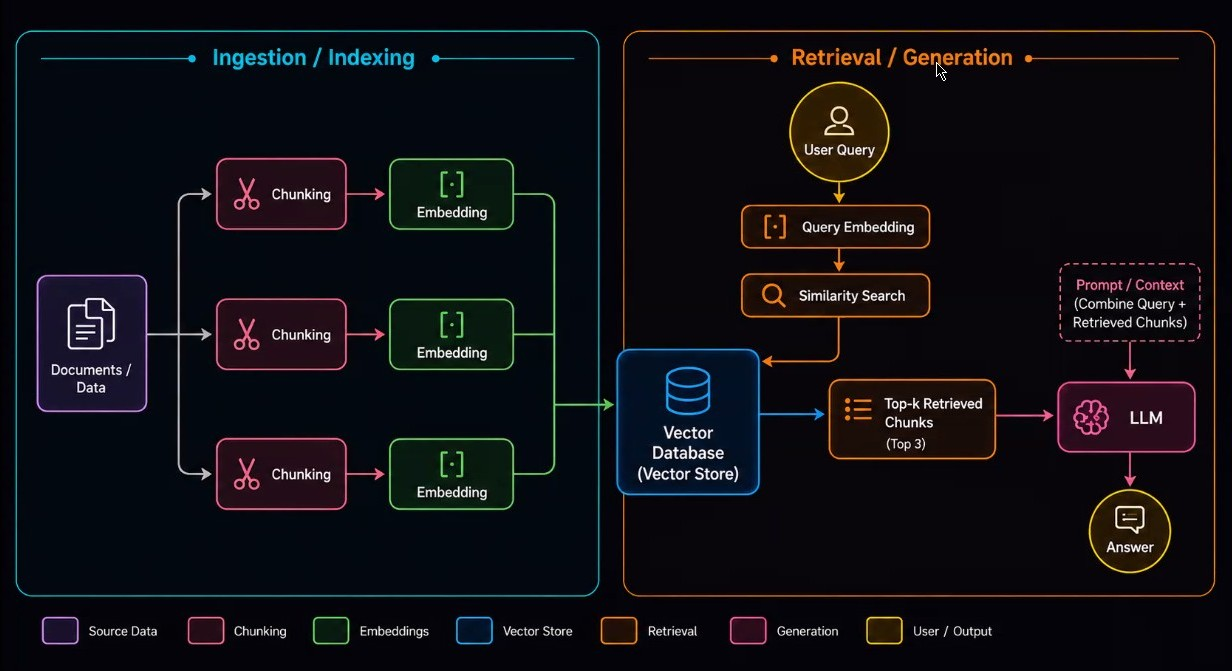

In [7]:
from IPython.display import Image, display
display(Image(filename='Research/RAG.jpg'))

##### **RAG vs Finetuning**

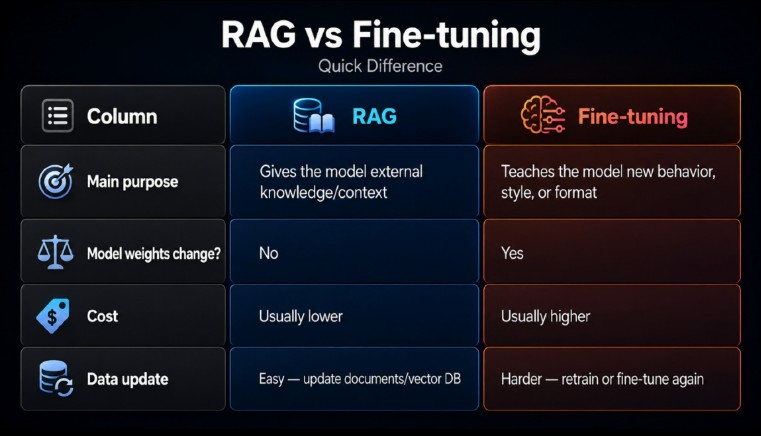

In [6]:
from IPython.display import Image, display
display(Image(filename='Research/RAGvsFineTuning.jpg'))

##### **Tools**

2 frameworks : Langchain and Langgraph(used for Agentic RAG)

*No need to explore other frameworks like CrewAI, Autogen, etc.* 

Agentic AI also revolves around Langchain and Langgraph

#### **Data Ingestion**

Data Parsing : Fetching / arranging the data

Langchain is a wrapper framework that provides all sort of services needed to build an AI applications. It doesn't have its own parser or models:
1) Document Loaders/Document Parsers
2) Methods of chunking
3) Access of Vector Databases
4) Models/LLMs/APIs
5) Integration with Cloud
6) Memory management
7) Chaining/LCEL

LangChain is not doing the low-level parsing by itself. It mainly provides a common wrapper/interface over different libraries and services. LangChain in itself is not a parsing library
Similarly, LangChain provides document loaders but many of thos eloaders internally use existing parsing libraries such as PyPDF, PyMuPDF, pdfplumber, python-docx, and others. 
In short, LangChain acts like a wrapper or integration layer that gives a common Document format i.e. page_content + metadata. This makes it easy to plug parsed documents into the RAG pipeline. 

LangChain wraps different parsing libraries so developers can use many data sources through one common interface. Its goal is not only parsing, but connecting parsing with chunking, embeddings, vector databases, retrievers, prompts and LLMs. This makes full RAG pipeline easier to build and maintain. 

##### **Tools/Frameworks for Data extraction**

Document AI & Parsing

- **Llama Parser** : OCR/PDF/docx/Layoput parsing/Table parsing/Metadata arranging
- **Docling** : OCR/PDF/docx/Layoput parsing/Table parsing/Metadata arranging
- **python-docx** : Docx type documents
- **PyMuPDF**
- **PdfPlumber**
- **Parsio**
- **Unstructured.io**
- **Azure Document Intelligence** : [PAID]
- **Google Document AI** : [PAID]
- **Amazon Textract** : [PAID]

##### **Vector Databases & Search**

- FAISS
- Chroma
- Qdrant
- Supabase
- pgvector
- Milvus
- Pinecone
- AWS OpenSearch
- Azure AI Search

#### **Generation**